<a href="https://colab.research.google.com/github/dineshck2023-cpu/cv_workshop/blob/main/day02cv_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

YOLO OUTOUT

Class label → What the object is (e.g., person, car, dog)

Bounding box → Rectangle showing where the object is in the image

Confidence score → How sure the model is about the prediction

In [ ]:
# Core libraries
import tensorflow as tf            # Main deep learning library
import numpy as np                # For numerical operations (arrays, math)
import matplotlib.pyplot as plt   # For plotting graphs and images

# Dataset
from tensorflow.keras.datasets import cifar10   # CIFAR-10 image dataset

# Model and layers
from tensorflow.keras import layers, models     # To build neural network models

# Pretrained model
from tensorflow.keras.applications import MobileNetV2   # Pretrained CNN model

# Utilities
from sklearn.metrics import classification_report, confusion_matrix  # Evaluation metrics
import seaborn as sns   # For better visualization (like heatmaps)

load dataset

In [ ]:
# Load CIFAR-10 dataset (automatically split into train and test)
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# x_train → training images
# y_train → labels for training images
# x_test → testing images
# y_test → labels for testing images

# Print shapes to understand the data structure
print("Train shape:", x_train.shape)
# Example: (50000, 32, 32, 3) -> 50k images, each 32x32 with 3 color channels

print("Test shape:", x_test.shape)
# Example: (10000, 32, 32, 3)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


Normalize data

In [ ]:
# Normalize pixel values (0–255 -> 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

Data augmentation

In [ ]:
# Data augmentation helps the model learn better by showing slightly modified images
# This reduces overfitting and improves performance on new data

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),     # Randomly flips images left ↔ right
    layers.RandomRotation(0.1),          # Slightly rotates images (10% range)
    layers.RandomZoom(0.1)               # Slightly zooms in/out
])

load pretrained model

In [ ]:
# Load MobileNetV2 model without the final classification layer (top layers)
base_model = MobileNetV2(input_shape=(32,32,3),
                         include_top=False,       # Remove default output layer
                         weights='imagenet')      # Use pretrained weights from ImageNet

# Freeze the base model so its learned features are not changed during training
base_model.trainable = False

/tmp/ipykernel_983/3232108708.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(32,32,3),


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


build advanced model

In [ ]:


# Build Advanced Model
# Build custom model on top of the pretrained base model
model = models.Sequential([
    data_augmentation,              # Apply random transformations to input images
    base_model,                     # Use pretrained MobileNetV2 as feature extractor
    layers.GlobalAveragePooling2D(),# Convert feature maps into a single vector
    layers.BatchNormalization(),    # Normalize features to make training stable
    layers.Dense(128, activation="relu"),  # Fully connected layer for learning patterns
    layers.Dropout(0.5),            # Randomly drop neurons to reduce overfitting
    layers.Dense(10, activation="softmax") # Output layer for 10 classes
])

# Display model architecture
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1, 1, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

compile model

In [ ]:
# Compile the model (configure how it learns)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # Optimizer to update weights
    loss='sparse_categorical_crossentropy',  # Loss function for multi-class classification
    metrics=['accuracy']  # Metric to track performance
)

add callbacks

In [ ]:
# Early stopping stops training when model stops improving (prevents overfitting)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Watch validation loss
    patience=3,  # Wait for 3 epochs before stopping if no improvement
    restore_best_weights=True  # Restore the best model weights after stopping
)

early stopping

In [ ]:
# Early stopping stops training when model stops improving (prevents overfitting)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',          # Watch validation loss
    patience=3,                  # Wait for 3 epochs before stopping if no improvement
    restore_best_weights=True    # Restore the best model weights after stopping
)

train model

In [ ]:
# Train the model on training data
history = model.fit(
    x_train, y_train,                 # Training data
    epochs=10,                        # Number of times the model sees the data
    validation_data=(x_test, y_test), # Check performance on test data after each epoch
    callbacks=[early_stop]            # Apply early stopping to avoid overfitting
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 96s 61ms/step - accuracy: 0.2671 - loss: 2.0016 - val_accuracy: 0.2937 - val_loss: 2.0532
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 56ms/step - accuracy: 0.2657 - loss: 1.9968 - val_accuracy: 0.2916 - val_loss: 2.0831
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.2700 - loss: 1.9921 - val_accuracy: 0.3024 - val_loss: 2.0752


In [ ]:
# Train the model on training data
history = model.fit(
    x_train, y_train,                 # Training data
    epochs=10,                        # Number of times the model sees the data
    validation_data=(x_test, y_test), # Check performance on test data after each epoch
    callbacks=[early_stop]            # Apply early stopping to avoid overfitting
)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.2690 - loss: 1.9950 - val_accuracy: 0.3018 - val_loss: 2.0777
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 51ms/step - accuracy: 0.2689 - loss: 1.9906 - val_accuracy: 0.2964 - val_loss: 2.0582
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.2675 - loss: 1.9945 - val_accuracy: 0.3091 - val_loss: 2.0683


1. Load pre-trained model
2. Freeze initial layers
3. Unfreeze top layers
4. Train partially

In [ ]:
# Unfreeze top layers of base model
base_model.trainable = True

# Freeze initial layers, train only deeper layers
for layer in base_model.layers[:100]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train again
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 237s 136ms/step - accuracy: 0.1473 - loss: 3.1845 - val_accuracy: 0.1618 - val_loss: 2.3028
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 199s 127ms/step - accuracy: 0.1889 - loss: 2.4961 - val_accuracy: 0.2309 - val_loss: 2.0973
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 201s 128ms/step - accuracy: 0.2199 - loss: 2.2423 - val_accuracy: 0.3032 - val_loss: 1.9433
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 198s 127ms/step - accuracy: 0.2451 - loss: 2.1061 - val_accuracy: 0.3360 - val_loss: 1.8641
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 200s 128ms/step - accuracy: 0.2680 - loss: 2.0116 - val_accuracy: 0.3614 - val_loss: 1.8042


evaluation model

313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step
              precision    recall  f1-score   support

           0       0.38      0.42      0.40      1000
           1       0.39      0.49      0.43      1000
           2       0.26      0.16      0.20      1000
           3       0.33      0.17      0.23      1000
           4       0.31      0.30      0.30      1000
           5       0.41      0.32      0.35      1000
           6       0.42      0.42      0.42      1000
           7       0.35      0.46      0.40      1000
           8       0.37      0.37      0.37      1000
           9       0.35      0.50      0.41      1000

    accuracy                           0.36     10000
   macro avg       0.36      0.36      0.35     10000
weighted avg       0.36      0.36      0.35     10000



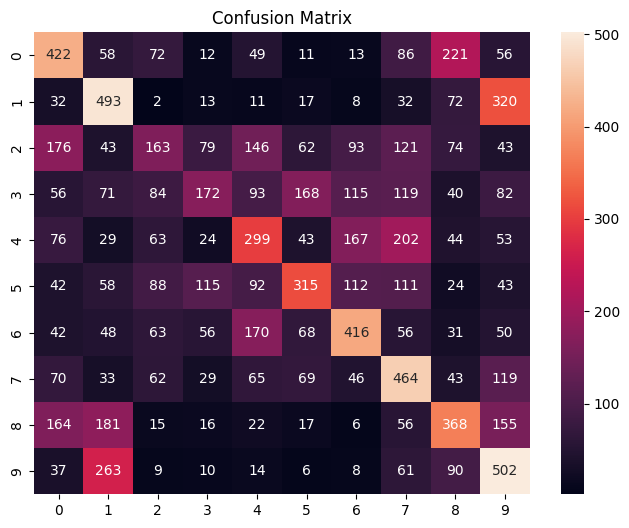

In [ ]:
# Predictions
y_pred = np.argmax(model.predict(x_test), axis=1)

# Classification report
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

yolo object detection

In [ ]:
# 🔴 YOLO Object Detection

# Install ultralytics
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.1 MB/s eta 0:00:00


In [ ]:
# Load YOLO model
from ultralytics import YOLO

yolo_model = YOLO('yolov8n.pt')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# Run detection on image
results = yolo_model('https://ultralytics.com/images/bus.jpg', save=True)


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 814.1ms
Speed: 25.6ms preprocess, 814.1ms inference, 71.3ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict


Count detected objects

In [ ]:
# Count detected objects
for p in results:
    print("Objects detected:", len(p.boxes))

Objects detected: 6


 Upload custom image

In [ ]:
# Upload custom image
from google.colab import files
uploaded = files.upload()


Saving image.jpg to image.jpg


In [ ]:
# Upload Custom Image
from google.colab import files
uploaded = files.upload()

for img in uploaded.keys():
    results = yolo_model(img, save=True)

Saving grassy-landscape-with-tree-raincloud.jpg to grassy-landscape-with-tree-raincloud (1).jpg

image 1/1 /content/grassy-landscape-with-tree-raincloud (1).jpg: 608x640 1 kite, 236.7ms
Speed: 5.5ms preprocess, 236.7ms inference, 3.3ms postprocess per image at shape (1, 3, 608, 640)
Results saved to /content/runs/detect/predict
